# M7 Assignment 2
Sentiment Analysis Using BERT

Context:
This dataset contains product reviews based on customer experiences such as quality, price, usage, and delivery. The reviews are written in simple, everyday language and represent different types of opinions similar to real-world online feedback.

Questions:
1. Import the dataset
2. Perform text preprocessing on the review column (such as cleaning text, removing special characters, and converting to lowercase).
3. Apply sentiment analysis using a pre-trained BERT model to predict the sentiment of each review.
4. Visualize the sentiment distribution by creating a bar chart of the predicted sentiments.

In [17]:
import warnings
warnings.filterwarnings("ignore")

## Import Libraries

This assignment follows the M7 Unit 8 transfer learning notebook, using a pretrained Hugging Face sentiment-analysis pipeline.

In [18]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import re

## Import the Dataset

Each line in `Customer Feedback.txt` is treated as one customer review.

In [19]:
# Read the text file (each line = one customer review)
with open("Customer Feedback.txt", "r", encoding="utf-8") as file:
    lines = file.readlines()

# Convert to DataFrame
data = pd.DataFrame(lines, columns=["review"])
data.head()

,review
0,The product quality feels really premium and d...
1,Delivery took longer than expected but packagi...
2,I tried this for a week and it works fine so f...
3,Not very happy with the stitching of the shirt\n
4,Battery backup is decent for daily use\n


## Text Preprocessing

Clean the review column by removing extra spaces, converting to lowercase, and removing special characters. The original review is kept because pretrained BERT-style models can also benefit from the natural sentence structure.

In [20]:
def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

data["clean_review"] = data["review"].apply(clean_text)
data.head()

,review,clean_review
0,The product quality feels really premium and d...,the product quality feels really premium and d...
1,Delivery took longer than expected but packagi...,delivery took longer than expected but packagi...
2,I tried this for a week and it works fine so f...,i tried this for a week and it works fine so far
3,Not very happy with the stitching of the shirt\n,not very happy with the stitching of the shirt
4,Battery backup is decent for daily use\n,battery backup is decent for daily use


## Model Initialization: BERT Sentiment Analysis

The pretrained sentiment-analysis pipeline loads the model, tokenizer, preprocessing steps, and prediction logic in one object.

In [21]:
# Initialize a pretrained model for sentiment analysis
bert_model = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## Apply Sentiment Analysis

In [22]:
data["bert_result"] = data["clean_review"].apply(lambda x: bert_model(str(x))[0])
data["predicted_sentiment"] = data["bert_result"].apply(lambda x: x["label"])
data["sentiment_score"] = data["bert_result"].apply(lambda x: x["score"])

data.head(20)

,review,clean_review,bert_result,predicted_sentiment,sentiment_score
0,The product quality feels really premium and d...,the product quality feels really premium and d...,"{'label': 'POSITIVE', 'score': 0.9996891021728...",POSITIVE,0.999689
1,Delivery took longer than expected but packagi...,delivery took longer than expected but packagi...,"{'label': 'POSITIVE', 'score': 0.9986785054206...",POSITIVE,0.998679
2,I tried this for a week and it works fine so f...,i tried this for a week and it works fine so far,"{'label': 'POSITIVE', 'score': 0.99983811378479}",POSITIVE,0.999838
3,Not very happy with the stitching of the shirt\n,not very happy with the stitching of the shirt,"{'label': 'NEGATIVE', 'score': 0.9996988773345...",NEGATIVE,0.999699
4,Battery backup is decent for daily use\n,battery backup is decent for daily use,"{'label': 'POSITIVE', 'score': 0.9974978566169...",POSITIVE,0.997498
5,Looks exactly like the pictures shown online\n,looks exactly like the pictures shown online,"{'label': 'NEGATIVE', 'score': 0.8973135948181...",NEGATIVE,0.897314
6,The material is softer than I expected\n,the material is softer than i expected,"{'label': 'NEGATIVE', 'score': 0.9724435210227...",NEGATIVE,0.972444
7,Setup process was confusing at first\n,setup process was confusing at first,"{'label': 'NEGATIVE', 'score': 0.9991896748542...",NEGATIVE,0.999190
8,Works well for basic usage\n,works well for basic usage,"{'label': 'POSITIVE', 'score': 0.99919193983078}",POSITIVE,0.999192
9,The color fades after a few washes\n,the color fades after a few washes,"{'label': 'NEGATIVE', 'score': 0.9994367957115...",NEGATIVE,0.999437


## Sentiment Counts

In [23]:
sentiment_counts = data["predicted_sentiment"].value_counts()
sentiment_counts

predicted_sentiment
POSITIVE    58
NEGATIVE    44
Name: count, dtype: int64

## Sentiment Distribution Bar Chart

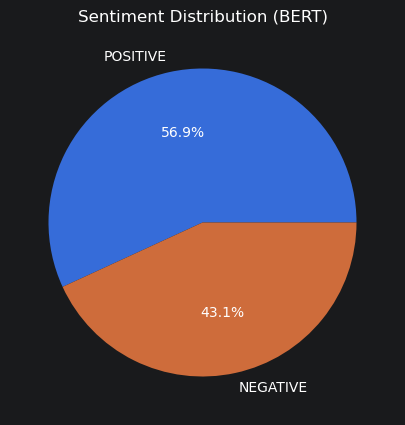

In [24]:
# Plot pie chart
plt.figure(figsize=(7, 5))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Sentiment Distribution (BERT)")
plt.show()

## Conclusion

The pretrained BERT-style sentiment model classified all 102 customer reviews and produced a confidence score for each prediction. In this run, the feedback distribution was slightly more positive than negative, with 58 reviews classified as POSITIVE and 44 classified as NEGATIVE. The pie chart summarizes this distribution and helps show the overall customer sentiment at a glance.